[2026-07-09 16:41:40] [info     ] 963766条
[2026-07-09 16:41:41] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-09 16:41:50] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-09 16:41:51] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-09 16:41:53] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2021-01-04 至 2024-12-31
[2026-07-09 16:41:53] [info     ] ========== 数据检查 ==========
[2026-07-09 16:41:53] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_m

时段,IC
2024-01-15~2024-02-08,0.0014
2024-09-24~2024-10-08,0.0244

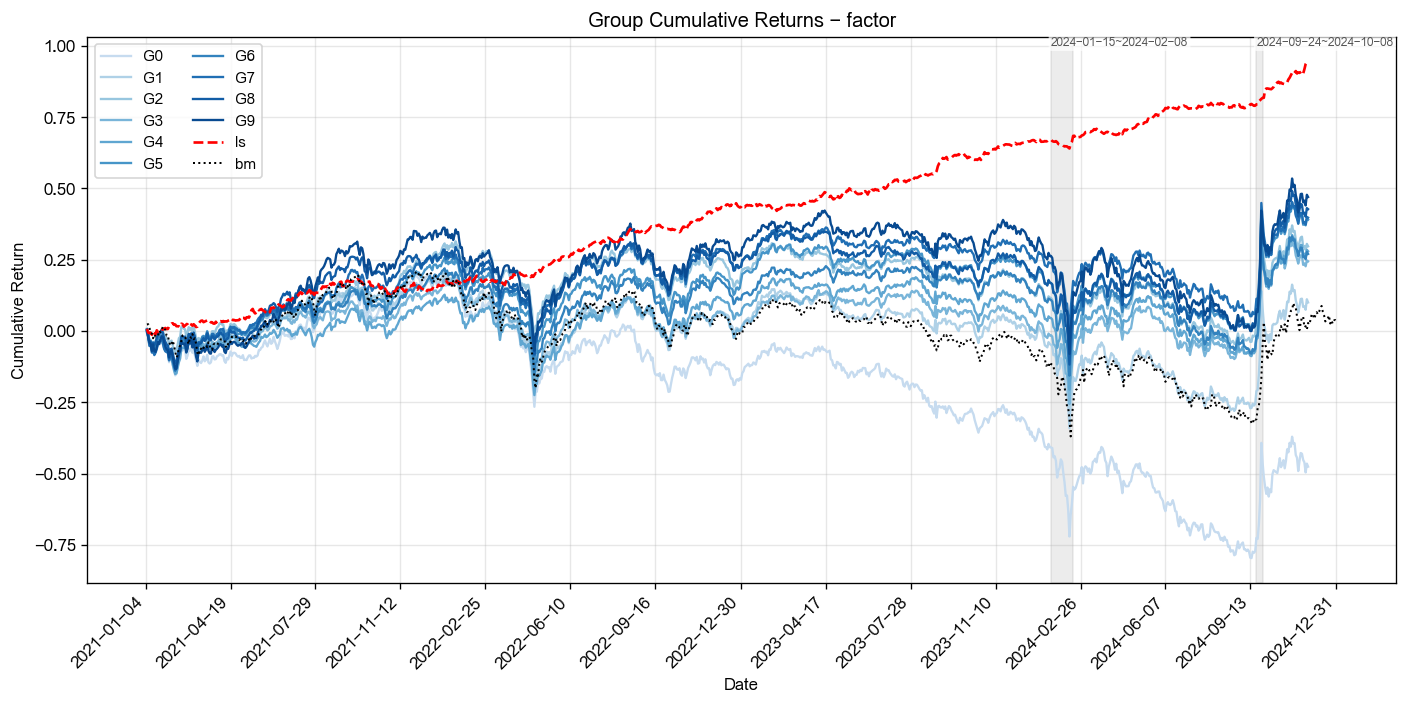
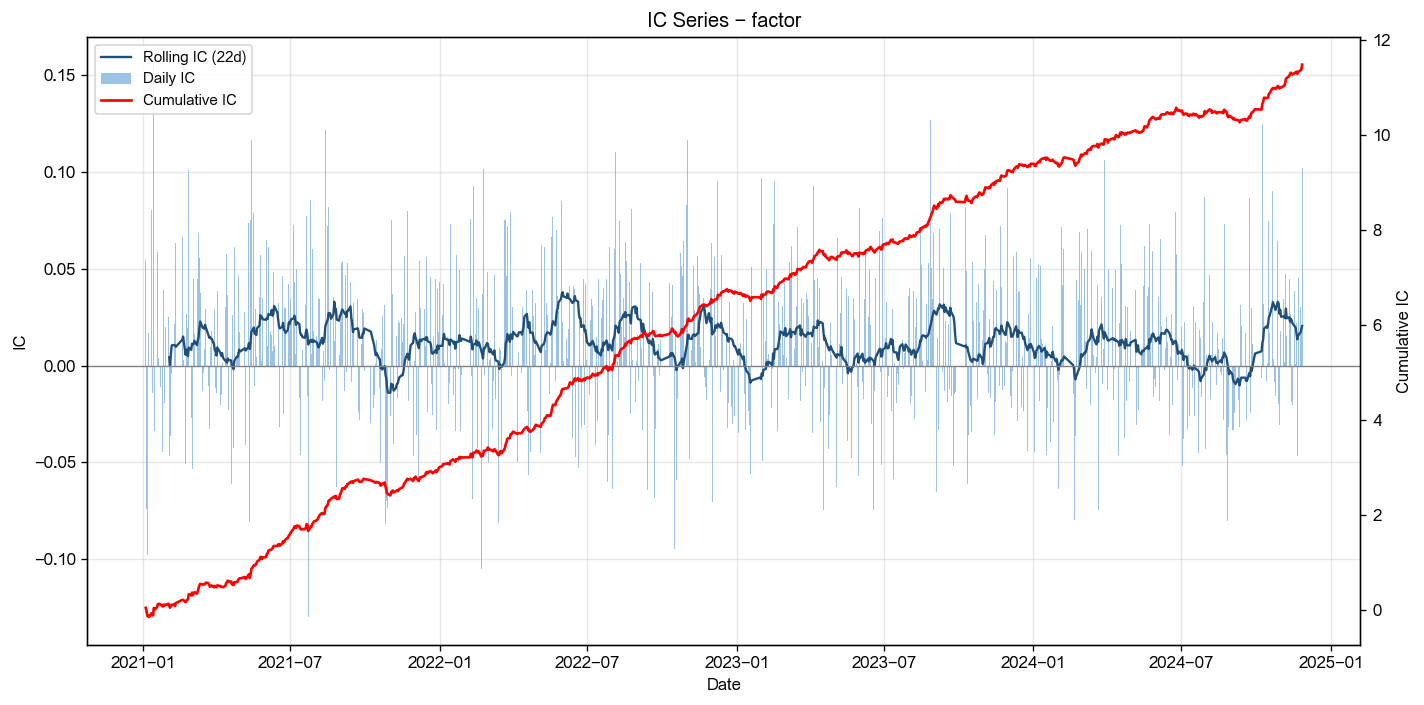
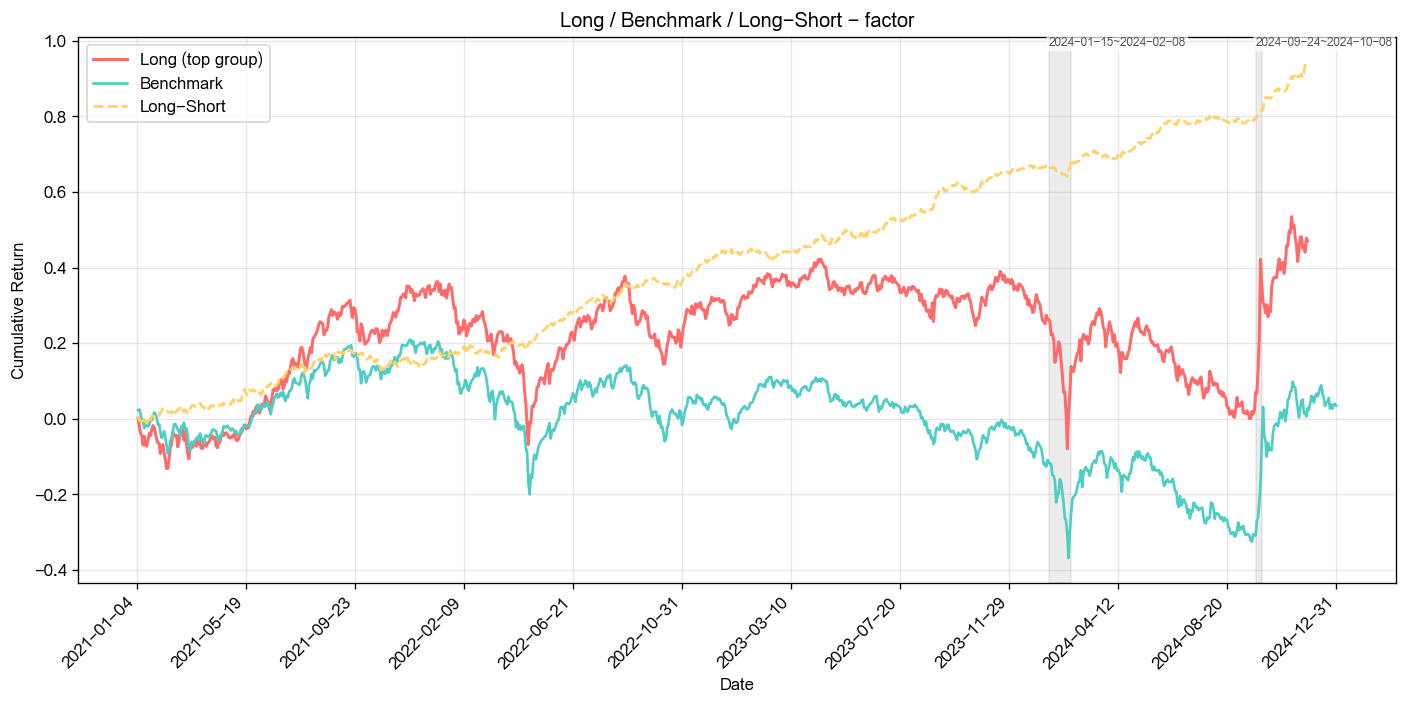
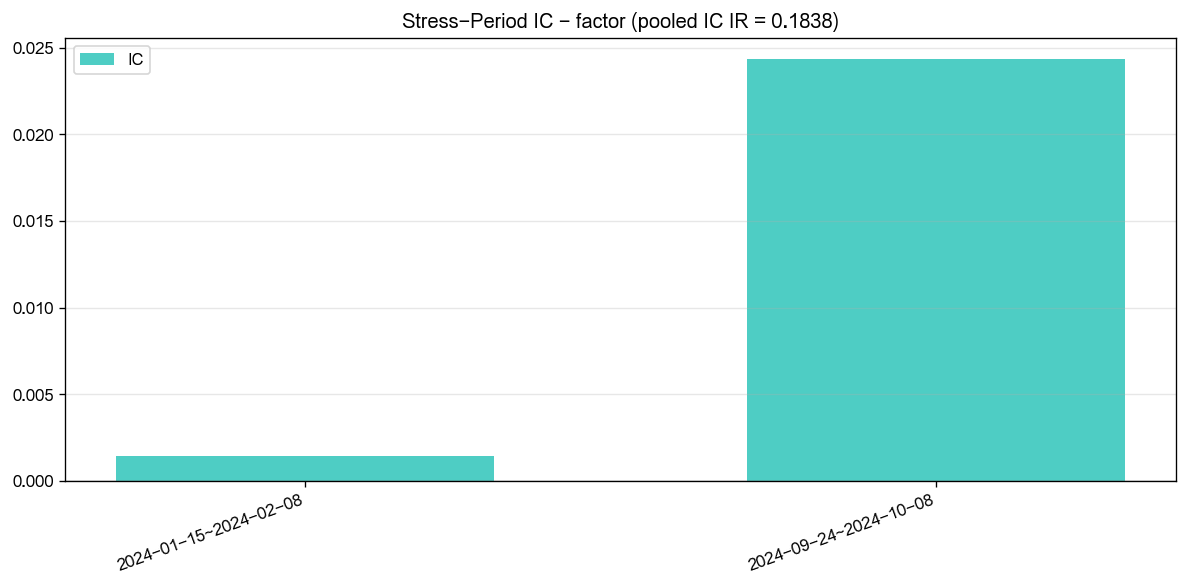
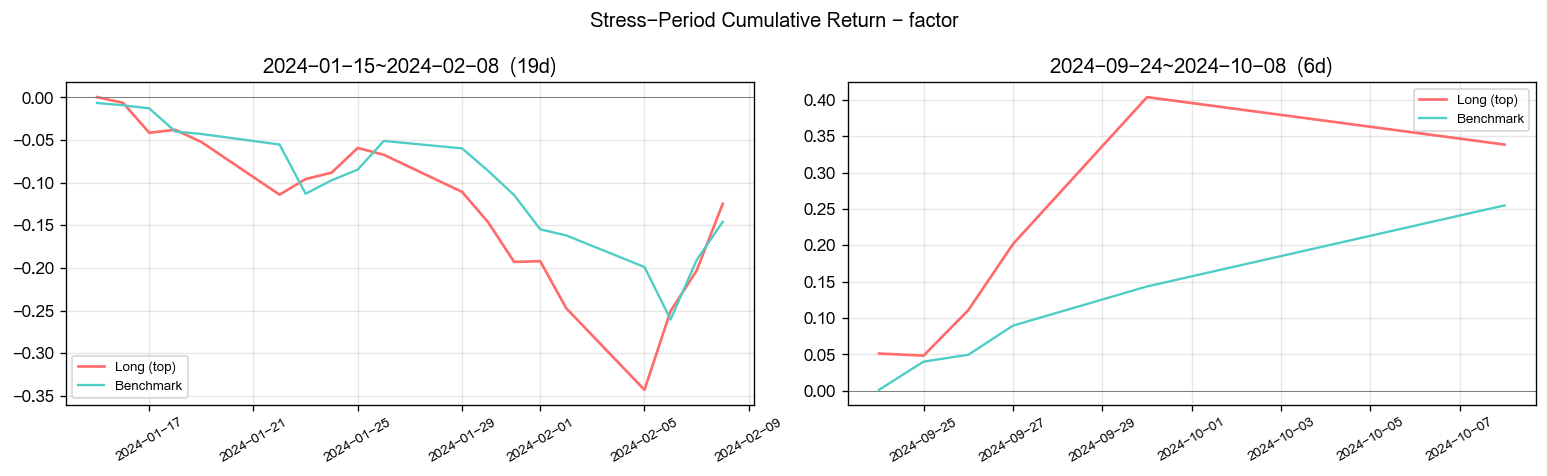

[2026-07-09 16:47:24] [info     ] ========== 因子池回归 ==========
[2026-07-09 16:47:26] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1753 rows=1604641 start_date=2021-01-04
[2026-07-09 16:47:29] [info     ] 获取收益率数据, 耗时: 4.8975 秒
[2026-07-09 16:47:34] [info     ] 滚动 Elastic Net 拟合, 耗时: 5.105 秒
[2026-07-09 16:47:34] [info     ] 统计 回归结果, 耗时: 0.0096 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,1.9034,0.0101,0.0053,0.9783
2,debt_to_asset_lf,1.4670,0.0091,0.0062,0.9783
3,momentum_5,1.4533,0.0168,0.0116,0.9565
4,net_active_buy_amount_main,1.4057,0.0200,0.0143,0.9565
5,volatility_5,1.4026,0.0143,0.0102,0.9348
6,amount,1.3951,0.0243,0.0174,0.9565
7,gross_profit_rate_ttm,1.3932,0.0126,0.0091,0.9783
8,bias_20,1.3455,0.0270,0.0201,0.9348
9,beta_000300SH_22,1.3392,0.0174,0.0130,0.9783
10,reversal_5,1.3273,0.0088,0.0066,0.9565

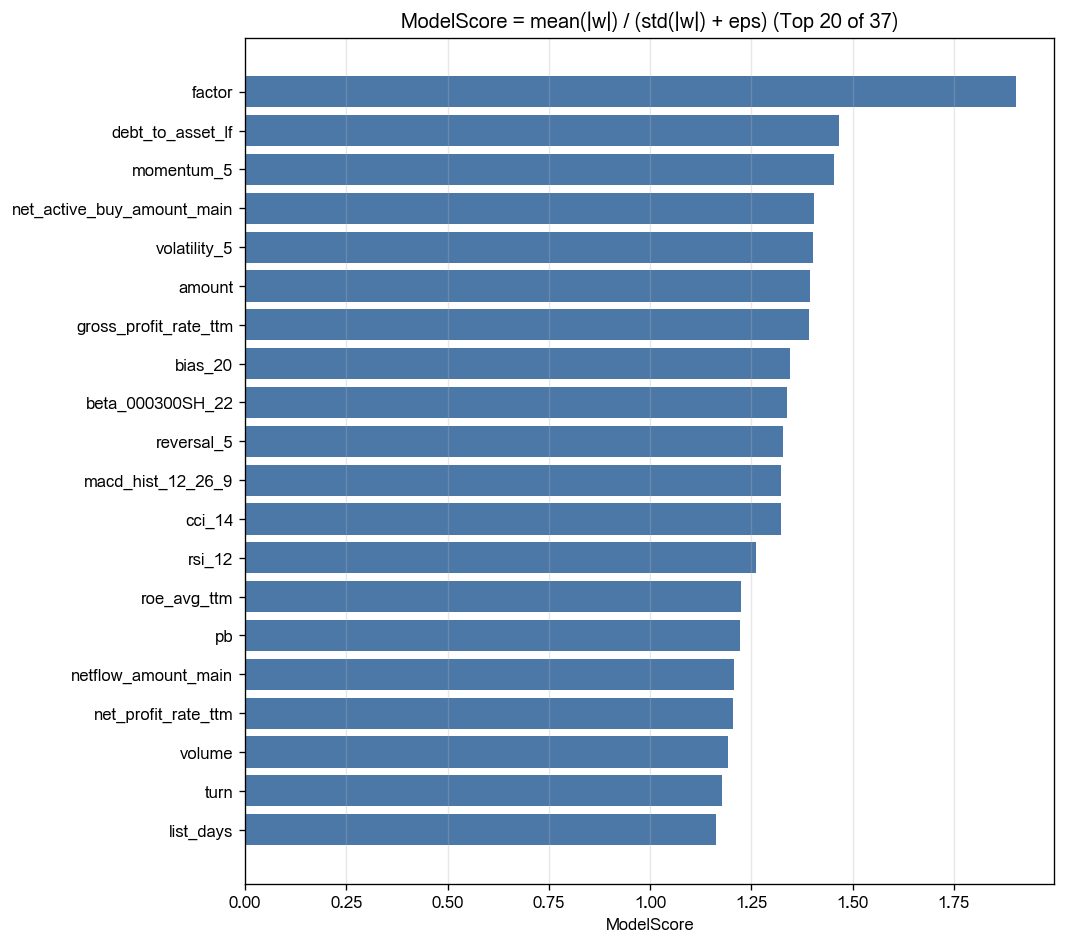
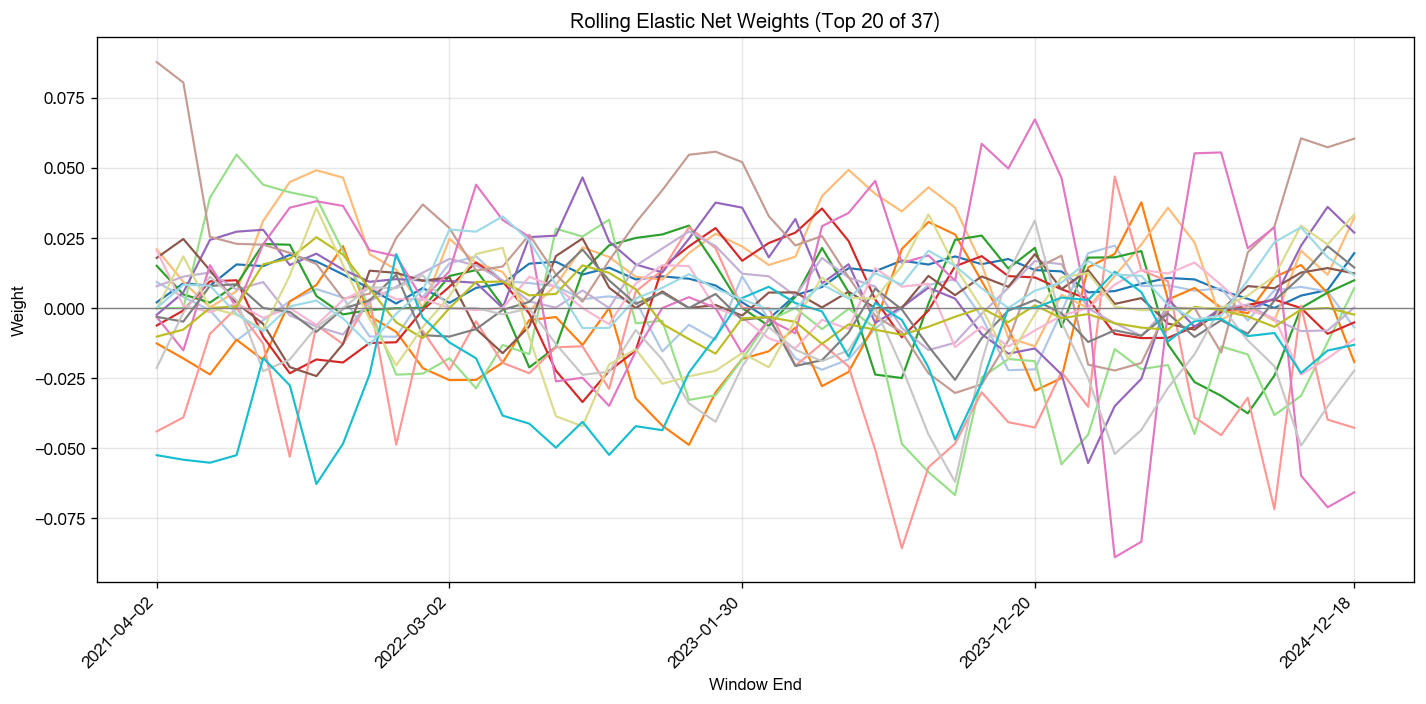
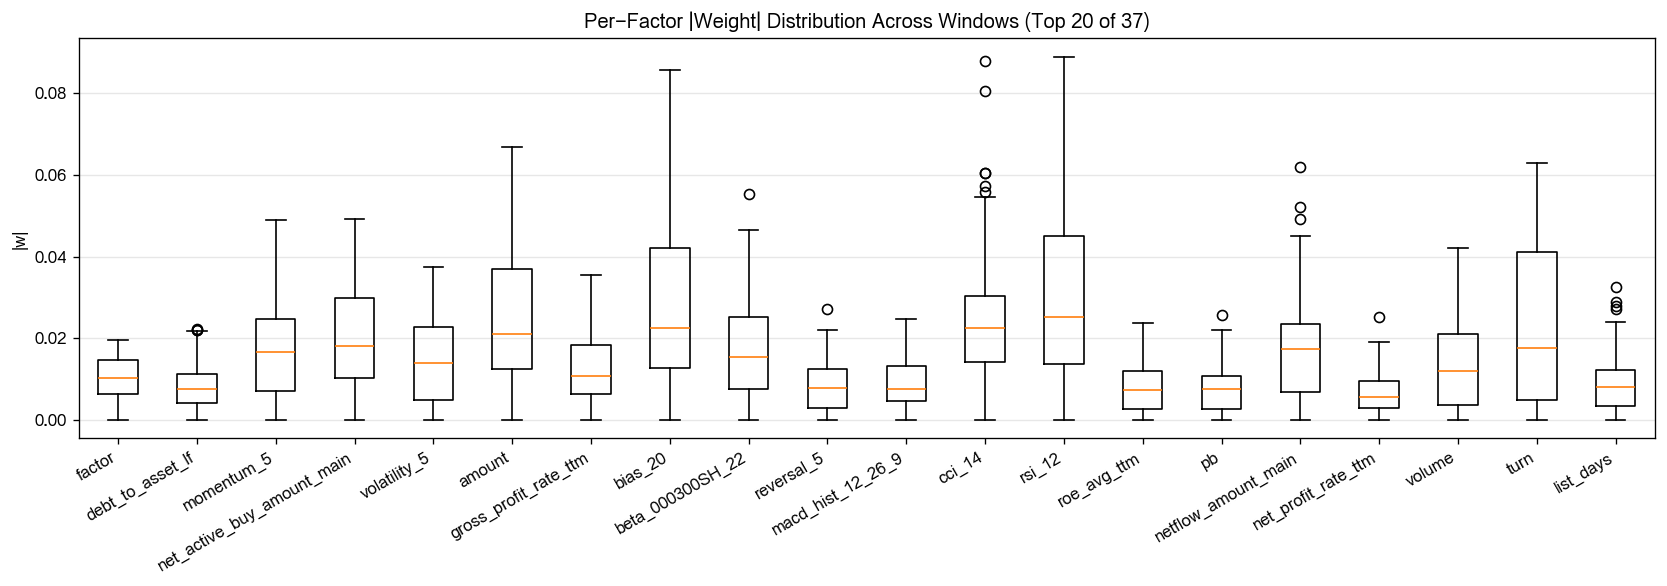
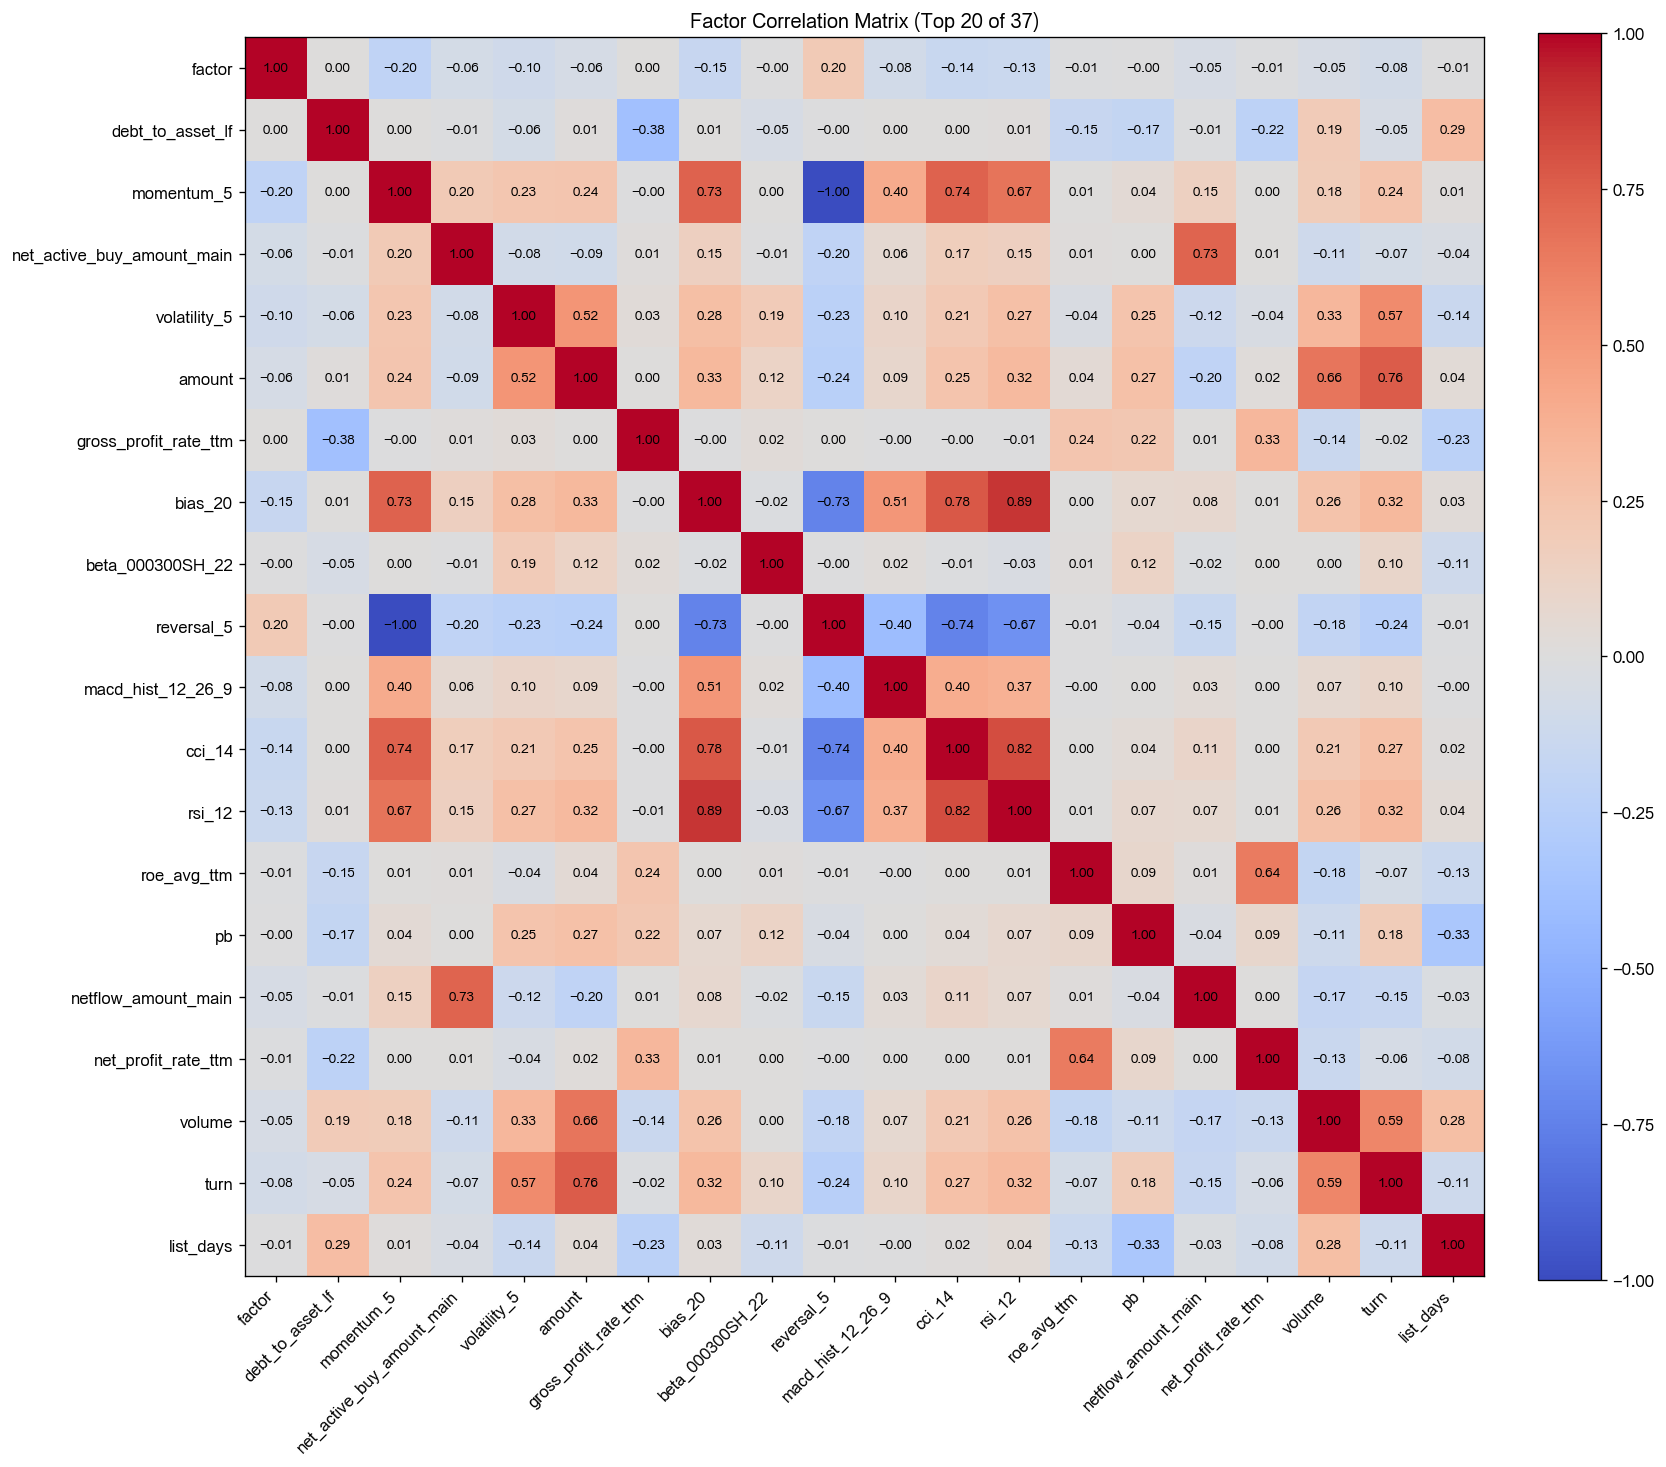

[2026-07-09 16:47:38] [warning  ] 返回的Outputs实例(size=143149362) 大于 64K, 将不会被缓存
[2026-07-09 16:47:38] [info     ] bigalpha_eval.v4 运行完成 [347.754s].


In [2]:
def main(datasources, start_date, end_date):
    """
    因子: barra_82_88 — Barra中性化块融合: 成交额信噪比(G0~G2) + Lz1取负(G6~G9)

    基于 Barra 中性化后的 block-based 分层分类:
      因子82 (amt_snr_5d): 低端有效块 G0~G2, IC>0
        amt_snr_5d = MA_5(amount) / STD_5(amount)
        Barra后ICIR=+6.17 (训练期), 断裂点: G2->G3
      因子88 (lz1): 高端有效块 G6~G9, IC<0
        lz1 = -decay_linear(vwap/close, 6)
        其中 vwap = amount/volume (近似)
        Barra后ICIR=-8.40 (训练期), 断裂点: G5->G6
      G3~G5 为过渡带

    融合逻辑:
      G0~G1: 纯因子82 z-score
      G2~G3: 50% 82 + 50% (-88)
      G4~G9: 纯因子88取负 z-score

    本地测试集 (2021-2024, Barra中性化后):
      ICIR=+5.18, LS Sharpe=+1.87
      对比: 82单独 ICIR=+2.25, 88单独 ICIR=-3.74

    数据: bigalpha_2026_bar1m (分钟K线聚合到日频)
    """
    import pandas as pd; import numpy as np; import dai
    bar1m_table = datasources["bar1m"]
    LOOKBACK = 40
    qs = pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK)

    # ================================================================
    # 共享日频聚合
    # ================================================================
    sql = f"""
    SELECT date_trunc('day', date)::DATE AS date, instrument,
           ARG_MIN(open, date) AS open, MAX(high) AS high, MIN(low) AS low,
           ARG_MAX(close, date) AS close, ARG_MIN(pre_close, date) AS pre_close,
           MAX(volume) AS volume, MAX(amount) AS amount,
           (ARG_MAX(close, date) / NULLIF(ARG_MIN(pre_close, date), 0) - 1) * 100 AS change_ratio
    FROM {bar1m_table}
    GROUP BY date_trunc('day', date)::DATE, instrument
    """
    df = dai.query(sql, filters={'date': [qs, end_date]}).df()
    df['date'] = pd.to_datetime(df['date']); df['instrument'] = df['instrument'].astype(str)
    df = df.sort_values(['instrument', 'date']).reset_index(drop=True)

    def w(s, n=5):
        m = s.median(); d = (s - m).abs().median()
        return s.clip(m - n * d, m + n * d)

    # ================================================================
    # 子因子A: amt_snr_5d = MA_5(amount) / STD_5(amount)
    # ================================================================
    df['ma5_amt'] = df.groupby('instrument')['amount'].transform(
        lambda x: x.rolling(5, min_periods=3).mean())
    df['std5_amt'] = df.groupby('instrument')['amount'].transform(
        lambda x: x.rolling(5, min_periods=3).std())
    df['f82_raw'] = df['ma5_amt'] / df['std5_amt'].replace(0, np.nan)

    # ================================================================
    # 子因子B: lz1 = -decay_linear(vwap/close, 6) (vwap = amount/volume)
    # ================================================================
    df['vwap'] = df['amount'] / df['volume'].replace(0, np.nan)
    df['vwap_ratio'] = df['vwap'] / df['close'].replace(0, np.nan)
    decay_w = np.array([1,2,3,4,5,6]) / 21  # recent-weighted
    df['f88_raw'] = -df.groupby('instrument')['vwap_ratio'].transform(
        lambda x: x.rolling(6, min_periods=3).apply(lambda y: np.dot(y[-len(y):], decay_w[-len(y):]), raw=True))

    # ================================================================
    # 截面 MAD(5) 去极值
    # ================================================================
    df['f82'] = df.groupby('date')['f82_raw'].transform(w)
    df['f88'] = df.groupby('date')['f88_raw'].transform(w)

    # ================================================================
    # 截面 z-score (88是负向因子, 取负使其与82同向)
    # ================================================================
    df['z82'] = df.groupby('date')['f82'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0)
    df['z88_neg'] = df.groupby('date')['f88'].transform(
        lambda x: -(x - x.mean()) / x.std() if x.std() > 0 else 0)

    # ================================================================
    # 块融合: 按f82的值分10组, 按块分配权重
    # ================================================================
    df = df.dropna(subset=['f82', 'f88'])
    df['group'] = df.groupby('date')['f82'].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))

    g = df['group']
    w82 = np.where(g <= 1, 1.0, np.where(g.isin([2, 3]), 0.5, 0.0))
    w88 = np.where(g.isin([2, 3]), 0.5, np.where(g >= 4, 1.0, 0.0))

    df['factor_raw'] = w82 * df['z82'] + w88 * df['z88_neg']

    # ================================================================
    # 最终截面 z-score + 去极值 + 成分股对齐
    # ================================================================
    df['factor'] = df.groupby('date')['factor_raw'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0)
    df['factor'] = df.groupby('date')['factor'].transform(w)
    df = df[(df['date'] >= pd.to_datetime(start_date)) & (df['date'] <= pd.to_datetime(end_date))]
    df['factor'] = df['factor'].replace([np.inf, -np.inf], np.nan); df = df.dropna(subset=['factor'])

    stk = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments",
                    filters={'date': [start_date, end_date]}).df()
    stk['instrument'] = stk['instrument'].astype(str)
    r = pd.merge(df[['date', 'instrument', 'factor']], stk, how='right', on=['date', 'instrument'])
    return r.dropna(subset=['factor'])[['date', 'instrument', 'factor']].reset_index(drop=True)


if __name__ == '__main__':
    from bigmodule import M; import dai, structlog
    d = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    sd, ed = '2021-01-01 00:00:00', '2024-12-31 23:59:59'
    fd = main(d, sd, ed); structlog.get_logger().info(f"{len(fd)}条")
    p = dai.query("SELECT * FROM bigalpha_2026_factorlib", filters={'date': [sd, ed]}).df()
    M.bigalpha_eval._latest(factor_data=fd, factor_pool=p, process_pools=False, show=True)
